In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('ford.csv')

In [3]:
df.shape

(17966, 9)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  str    
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  str    
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  str    
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), str(3)
memory usage: 1.6 MB


In [5]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [11]:
df.duplicated().sum()

np.int64(0)

In [10]:
df=df[df.duplicated()!=True]

In [12]:
df.info()

<class 'pandas.DataFrame'>
Index: 17812 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17812 non-null  str    
 1   year          17812 non-null  int64  
 2   price         17812 non-null  int64  
 3   transmission  17812 non-null  str    
 4   mileage       17812 non-null  int64  
 5   fuelType      17812 non-null  str    
 6   tax           17812 non-null  int64  
 7   mpg           17812 non-null  float64
 8   engineSize    17812 non-null  float64
dtypes: float64(2), int64(4), str(3)
memory usage: 1.7 MB


In [13]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17812.000000,17812.000000,17812.000000,17812.000000,17812.000000,17812.000000
mean,2016.862396,12269.556310,23381.146362,113.315012,57.908696,1.350623
std,2.052039,4736.285417,19419.011045,62.034603,10.132696,0.432581
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,10000.000000,30.000000,52.300000,1.000000
50%,2017.000000,11288.000000,18277.000000,145.000000,58.900000,1.200000
75%,2018.000000,15295.000000,31098.500000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [14]:
cols=['year','mileage','tax','mpg','engineSize']

<Axes: xlabel='price', ylabel='Count'>

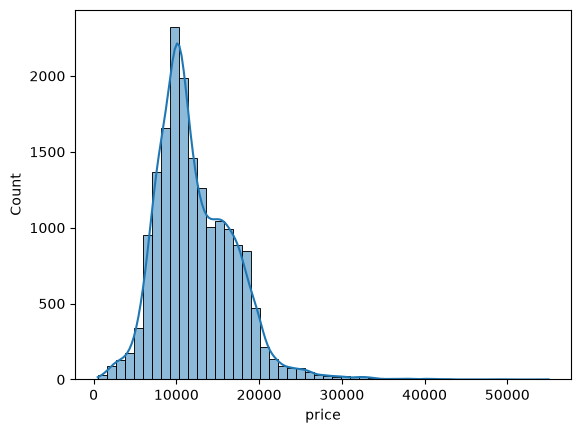

In [17]:
sns.histplot(df['price'],kde=True,bins=50)

<Axes: >

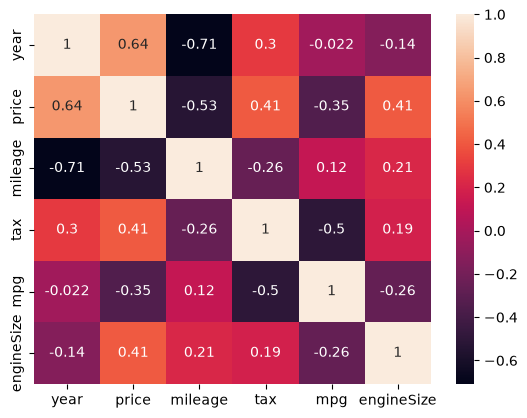

In [18]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

<Axes: xlabel='price', ylabel='model'>

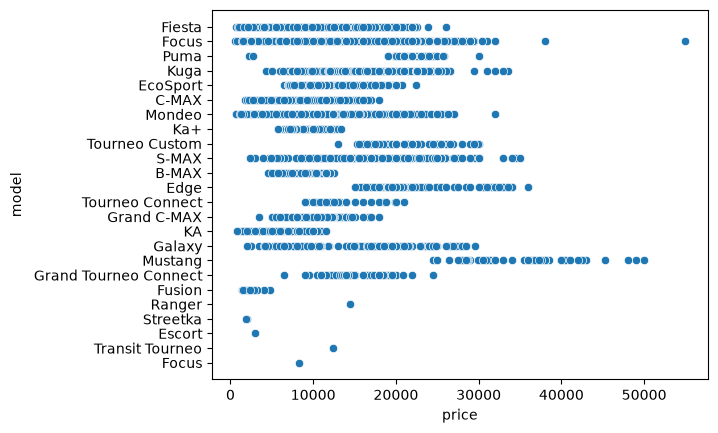

In [129]:
sns.scatterplot(data=df,y='model',x='price')

<Axes: xlabel='count', ylabel='model'>

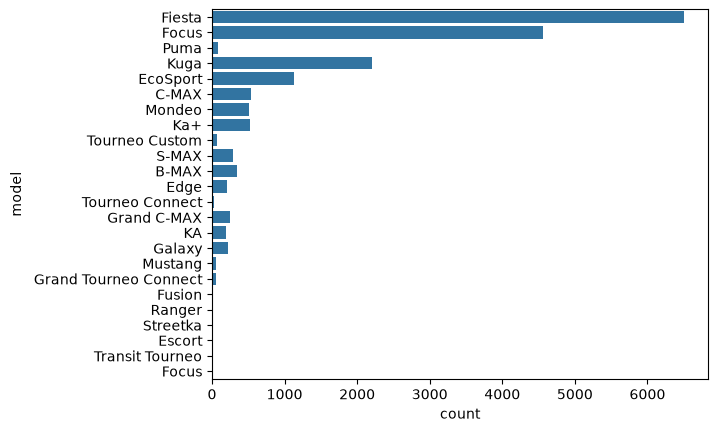

In [20]:
sns.countplot(df['model'])

<Axes: xlabel='count', ylabel='transmission'>

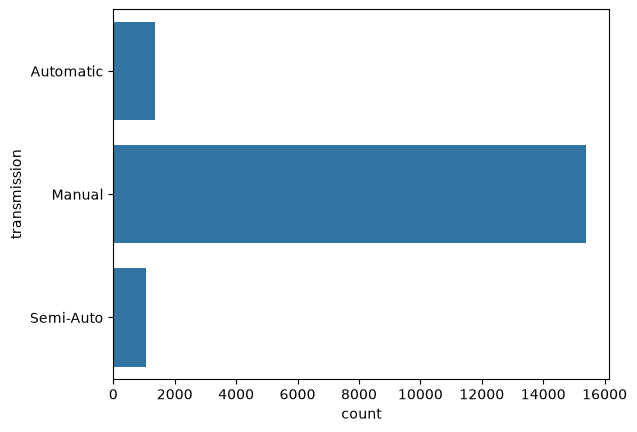

In [21]:
sns.countplot(df['transmission'])

<Axes: xlabel='count', ylabel='fuelType'>

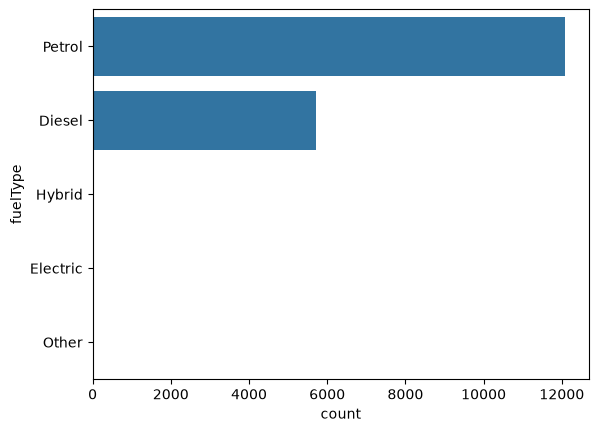

In [22]:
sns.countplot(df['fuelType'])

In [23]:
df['fuelType'].value_counts()

fuelType
Petrol      12081
Diesel       5706
Hybrid         22
Electric        2
Other           1
Name: count, dtype: int64

In [163]:
df["fuelType"] = df["fuelType"].replace({
    "Hybrid": "Other",
    "Electric": "Other"
})

In [164]:
X=df.drop('price',axis=1)
y=df['price']

In [165]:
X_encoded=pd.get_dummies(X,drop_first=True)

In [167]:
X_encoded.head()

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ S-MAX,model_ Streetka,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Other,fuelType_Petrol
0,2017,15944,150,57.7,1.0,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
1,2018,9083,150,57.7,1.0,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
2,2017,12456,150,57.7,1.0,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
3,2019,10460,145,40.3,1.5,False,False,False,False,True,...,False,False,False,False,False,False,True,False,False,True
4,2019,1482,145,48.7,1.0,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True


In [168]:
X_encoded=X_encoded.astype(int)

In [169]:
from sklearn.preprocessing import LabelEncoder
encode=LabelEncoder()
cols=['model','transmission','fuelType']
X_label=X.copy()
for i in cols:
    X_label[i]=encode.fit_transform(X_label[i])

In [170]:
X_label.head()

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,5,2017,0,15944,2,150,57.7,1.0
1,6,2018,1,9083,2,150,57.7,1.0
2,6,2017,1,12456,2,150,57.7,1.0
3,5,2019,1,10460,2,145,40.3,1.5
4,5,2019,0,1482,2,145,48.7,1.0


In [171]:
X_label['transmission'].value_counts()

transmission
1    15383
0     1354
2     1075
Name: count, dtype: int64

In [172]:
X['transmission'].value_counts()

transmission
Manual       15383
Automatic     1354
Semi-Auto     1075
Name: count, dtype: int64

In [173]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
cols=['year','mileage','tax','mpg']
X_encoded[cols]=scaler.fit_transform(X_encoded[cols])

In [174]:
X_encoded

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ S-MAX,model_ Streetka,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Other,fuelType_Petrol
0,0.067059,-0.382994,0.591380,-0.042291,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
1,0.554393,-0.736317,0.591380,-0.042291,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
2,0.067059,-0.562616,0.591380,-0.042291,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
3,1.041726,-0.665405,0.510777,-1.720193,1,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,1
4,1.041726,-1.127749,0.510777,-0.930592,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,0.067059,-0.344061,0.591380,-1.029292,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
17962,-1.394942,0.891875,-1.343079,-0.042291,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
17963,-0.907608,-0.843071,-1.504284,0.944711,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
17964,0.554393,-0.946220,0.510777,-0.042291,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1


In [175]:
X_encoded.columns

Index(['year', 'mileage', 'tax', 'mpg', 'engineSize', 'model_ C-MAX',
       'model_ EcoSport', 'model_ Edge', 'model_ Escort', 'model_ Fiesta',
       'model_ Focus', 'model_ Fusion', 'model_ Galaxy', 'model_ Grand C-MAX',
       'model_ Grand Tourneo Connect', 'model_ KA', 'model_ Ka+',
       'model_ Kuga', 'model_ Mondeo', 'model_ Mustang', 'model_ Puma',
       'model_ Ranger', 'model_ S-MAX', 'model_ Streetka',
       'model_ Tourneo Connect', 'model_ Tourneo Custom',
       'model_ Transit Tourneo', 'model_Focus', 'transmission_Manual',
       'transmission_Semi-Auto', 'fuelType_Other', 'fuelType_Petrol'],
      dtype='str')

In [176]:
cols=['year', 'mileage', 'tax', 'mpg', 'engineSize', 'model_ C-MAX',
       'model_ EcoSport', 'model_ Edge', 'model_ Escort', 'model_ Fiesta',
       'model_ Focus', 'model_ Fusion', 'model_ Galaxy', 'model_ Grand C-MAX',
       'model_ Grand Tourneo Connect', 'model_ KA', 'model_ Ka+',
       'model_ Kuga', 'model_ Mondeo', 'model_ Mustang', 'model_ Puma',
       'model_ Ranger', 'model_ S-MAX', 'model_ Streetka',
       'model_ Tourneo Connect', 'model_ Tourneo Custom',
       'model_ Transit Tourneo', 'model_Focus', 'transmission_Manual',
       'transmission_Semi-Auto', 'fuelType_Other', 'fuelType_Petrol']

In [177]:
X_encoded[cols]=scaler.fit_transform(X_encoded[cols])

In [178]:
X_encoded

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ S-MAX,model_ Streetka,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Other,fuelType_Petrol
0,0.067059,-0.382994,0.591380,-0.042291,-0.446958,-0.177155,-0.259896,-0.107903,-0.007493,1.317770,...,-0.129548,-0.010597,-0.042424,-0.062361,-0.007493,-0.007493,-2.516557,-0.253434,-0.03749,0.688753
1,0.554393,-0.736317,0.591380,-0.042291,-0.446958,-0.177155,-0.259896,-0.107903,-0.007493,-0.758858,...,-0.129548,-0.010597,-0.042424,-0.062361,-0.007493,-0.007493,0.397368,-0.253434,-0.03749,0.688753
2,0.067059,-0.562616,0.591380,-0.042291,-0.446958,-0.177155,-0.259896,-0.107903,-0.007493,-0.758858,...,-0.129548,-0.010597,-0.042424,-0.062361,-0.007493,-0.007493,0.397368,-0.253434,-0.03749,0.688753
3,1.041726,-0.665405,0.510777,-1.720193,-0.446958,-0.177155,-0.259896,-0.107903,-0.007493,1.317770,...,-0.129548,-0.010597,-0.042424,-0.062361,-0.007493,-0.007493,0.397368,-0.253434,-0.03749,0.688753
4,1.041726,-1.127749,0.510777,-0.930592,-0.446958,-0.177155,-0.259896,-0.107903,-0.007493,1.317770,...,-0.129548,-0.010597,-0.042424,-0.062361,-0.007493,-0.007493,-2.516557,-0.253434,-0.03749,0.688753
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,0.067059,-0.344061,0.591380,-1.029292,-0.446958,-0.177155,-0.259896,-0.107903,-0.007493,-0.758858,...,-0.129548,-0.010597,-0.042424,-0.062361,-0.007493,-0.007493,0.397368,-0.253434,-0.03749,0.688753
17962,-1.394942,0.891875,-1.343079,-0.042291,-0.446958,-0.177155,-0.259896,-0.107903,-0.007493,-0.758858,...,-0.129548,-0.010597,-0.042424,-0.062361,-0.007493,-0.007493,0.397368,-0.253434,-0.03749,0.688753
17963,-0.907608,-0.843071,-1.504284,0.944711,-0.446958,-0.177155,-0.259896,-0.107903,-0.007493,-0.758858,...,-0.129548,-0.010597,-0.042424,-0.062361,-0.007493,-0.007493,0.397368,-0.253434,-0.03749,-1.451898
17964,0.554393,-0.946220,0.510777,-0.042291,-0.446958,-0.177155,-0.259896,-0.107903,-0.007493,-0.758858,...,-0.129548,-0.010597,-0.042424,-0.062361,-0.007493,-0.007493,0.397368,-0.253434,-0.03749,0.688753


In [179]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [180]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.20, random_state=42)

In [181]:
model1=LinearRegression()
model1.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](32,)","[ 2159.35,-1197.38, -10.04,..., -52.29, 285.48, -531.96]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](32,)","['year','mileage','tax',...,'transmission_Semi-Auto','fuelType_Other', 'fuelType_Petrol']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.228e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,32
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(32)


In [182]:
y_pred=model1.predict(X_test)

In [183]:
r2=r2_score(y_test,y_pred)
r2

0.8259046848925202

In [184]:
n=X_encoded.shape[0]
p=X_encoded.shape[1]

In [185]:
absolute_r2=1-((1-r2)*(n-1)/(n-p-1))

In [186]:
absolute_r2

0.825591334868141

In [161]:
X_train,X_test, y_train, y_test = train_test_split(X_label, y, test_size=0.20, random_state=42)

In [162]:
from scipy.stats import pearsonr
correlations = {
    col:pearsonr(X_encoded[col],y)[0]
    for col in cols   
}
correlation_df=pd.DataFrame(list(correlations.items()),columns=['Feature', 'Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation',ascending=False)


,Feature,Pearson Correlation
0,year,0.635715
4,engineSize,0.495567
2,tax,0.405969
17,model_ Kuga,0.281926
19,model_ Mustang,0.267520
7,model_ Edge,0.237867
22,model_ S-MAX,0.147319
29,transmission_Semi-Auto,0.140648
12,model_ Galaxy,0.133839
20,model_ Puma,0.129067


In [117]:
cols=[x for x in correlations if abs(correlations[x])>0.2]
cols

['year',
 'mileage',
 'tax',
 'mpg',
 'engineSize',
 'model_ Edge',
 'model_ Fiesta',
 'model_ Kuga',
 'model_ Mustang',
 'transmission_Manual',
 'fuelType_Petrol']

In [118]:
df_final=X_encoded[cols]

In [124]:
X_train,X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.20, random_state=42)

In [125]:
model2=LinearRegression()
model2.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](34,)","[ 2156.88,-1201.47, -14.96,..., 8629.8 , 967.09,-1155.02]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](34,)","['year','mileage','tax',...,'fuelType_Hybrid','fuelType_Other', 'fuelType_Petrol']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,9209
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,34
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(34)


In [126]:
y_pred=model2.predict(X_test)

In [127]:
r2=r2_score(y_test,y_pred)
r2

0.8256860539909181